In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

### Load the house price dataset

In [2]:
df = pd.read_csv(r'..\Data\housing_price_dataset.csv')
df1 = df.copy()
df.head()

,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
0,2126,4,1,Rural,1969,215355.283618
1,2459,3,2,Rural,1980,195014.221626
2,1860,2,1,Suburb,1970,306891.012076
3,2294,2,1,Urban,1996,206786.787153
4,2130,5,2,Suburb,2001,272436.239065


### EDA and Data Wrangling

In [3]:
df.describe(include="all")

,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
count,50000.000000,50000.000000,50000.000000,50000,50000.000000,50000.000000
unique,NaN,NaN,NaN,3,NaN,NaN
top,NaN,NaN,NaN,Suburb,NaN,NaN
freq,NaN,NaN,NaN,16721,NaN,NaN
mean,2006.374680,3.498700,1.995420,NaN,1985.404420,224827.325151
std,575.513241,1.116326,0.815851,NaN,20.719377,76141.842966
min,1000.000000,2.000000,1.000000,NaN,1950.000000,-36588.165397
25%,1513.000000,3.000000,1.000000,NaN,1967.000000,169955.860225
50%,2007.000000,3.000000,2.000000,NaN,1985.000000,225052.141166
75%,2506.000000,4.000000,3.000000,NaN,2003.000000,279373.630052


In [4]:
# Check for empty 
df.isna().sum()

SquareFeet      0
Bedrooms        0
Bathrooms       0
Neighborhood    0
YearBuilt       0
Price           0
dtype: int64

In [5]:
# Check Datatype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SquareFeet    50000 non-null  int64  
 1   Bedrooms      50000 non-null  int64  
 2   Bathrooms     50000 non-null  int64  
 3   Neighborhood  50000 non-null  object 
 4   YearBuilt     50000 non-null  int64  
 5   Price         50000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 2.3+ MB


### Outlier Detection and Removal

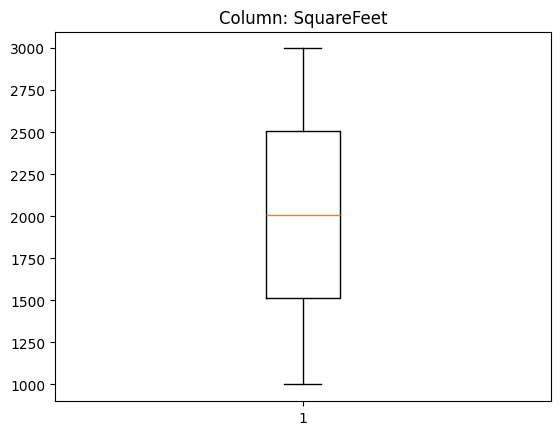

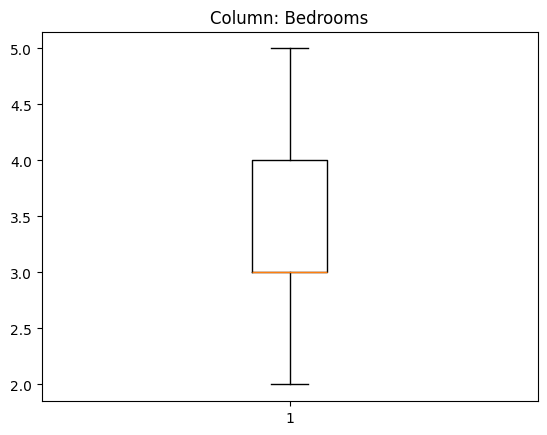

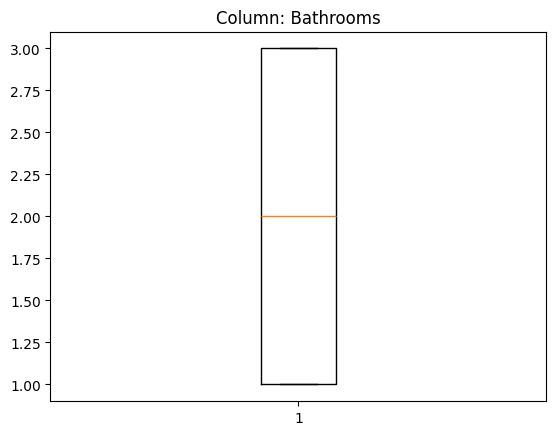

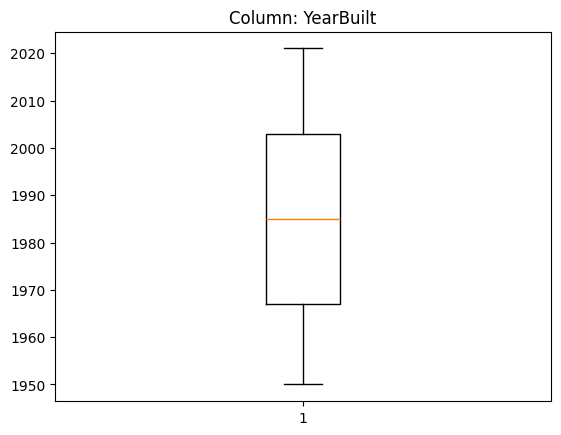

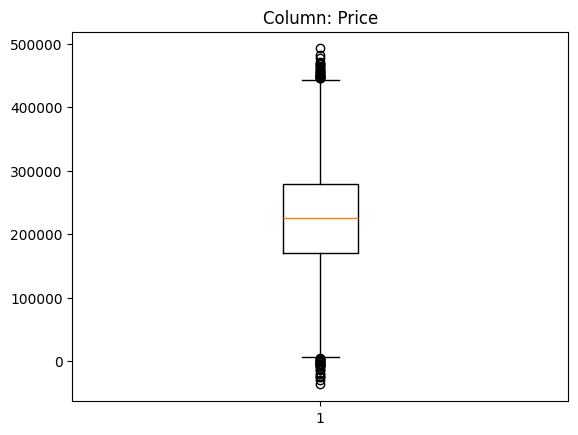

In [6]:
# Check for outliers 

for cols in ['SquareFeet','Bedrooms', 'Bathrooms','YearBuilt','Price']:
    plt.boxplot(df[cols])
    plt.title(f'Column: {cols}')
    plt.show()

In [7]:
# Potential outliers in PRICE 
df['Price'].describe(include="all")

count     50000.000000
mean     224827.325151
std       76141.842966
min      -36588.165397
25%      169955.860225
50%      225052.141166
75%      279373.630052
max      492195.259972
Name: Price, dtype: float64

In [8]:
# Price cant be below zero so drop which are < 0
df.drop(df[df.Price <= 0].index, axis = 0, inplace = True)

In [9]:
# Feature Enginnering 
df['Age'] = 2025 - df['YearBuilt']

In [10]:
df.describe(include="all")

,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price,Age
count,49978.000000,49978.000000,49978.000000,49978,49978.000000,49978.000000,49978.000000
unique,NaN,NaN,NaN,3,NaN,NaN,NaN
top,NaN,NaN,NaN,Suburb,NaN,NaN,NaN
freq,NaN,NaN,NaN,16716,NaN,NaN,NaN
mean,2006.752551,3.498659,1.995458,NaN,1985.404338,224931.667960,39.595662
std,575.350298,1.116325,0.815859,NaN,20.718407,75995.682992,20.718407
min,1000.000000,2.000000,1.000000,NaN,1950.000000,154.779120,4.000000
25%,1514.000000,3.000000,1.000000,NaN,1967.000000,170007.487130,22.000000
50%,2008.000000,3.000000,2.000000,NaN,1985.000000,225100.123857,40.000000
75%,2506.000000,4.000000,3.000000,NaN,2003.000000,279395.826288,58.000000


### Univariate Analysis

SquareFeet skewness: -0.01


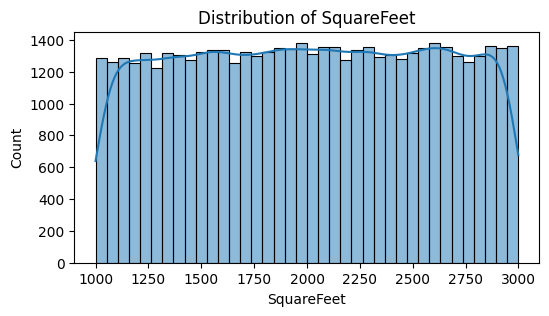

Bedrooms skewness: 0.00


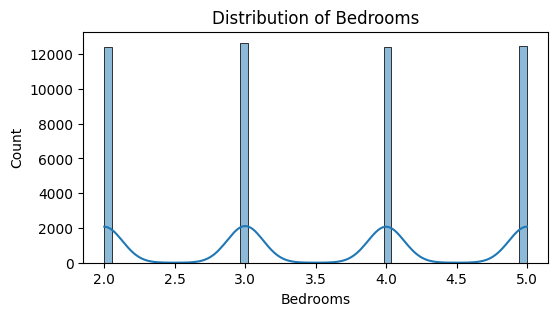

Bathrooms skewness: 0.01


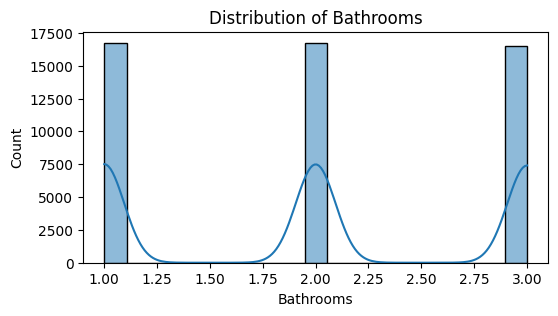

YearBuilt skewness: 0.01


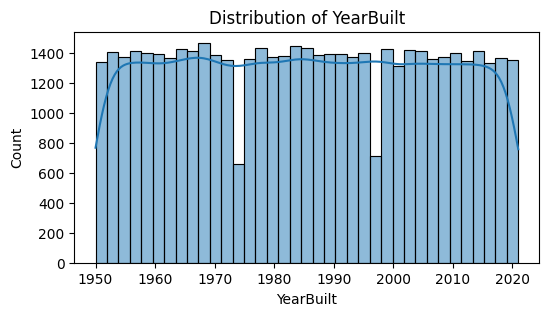

Price skewness: 0.00


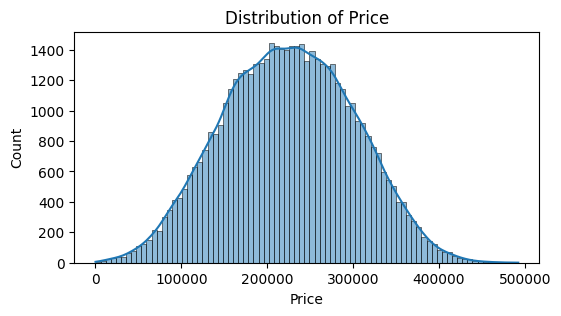

Age skewness: -0.01


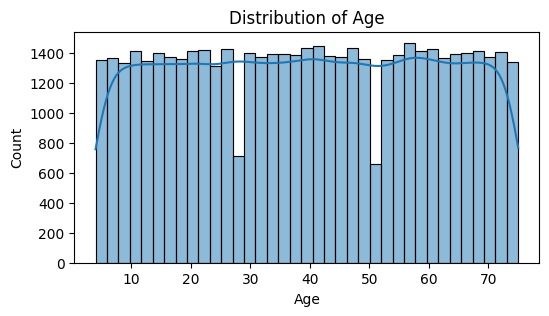

In [11]:
# Numeric variables
numeric_cols = ['SquareFeet','Bedrooms', 'Bathrooms','YearBuilt','Price','Age']
for col in numeric_cols:
    print(f"{col} skewness: {df[col].skew():.2f}")
    plt.figure(figsize=(6, 3))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

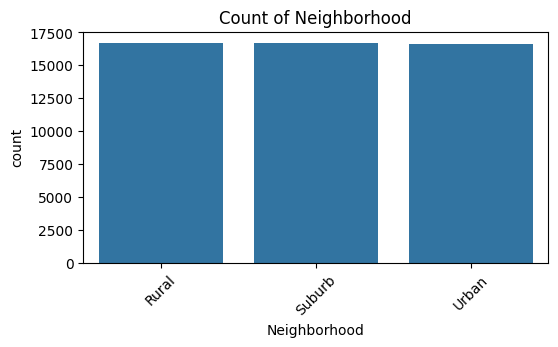

In [12]:
categorical_cols = ['Neighborhood']
for col in categorical_cols:
    plt.figure(figsize=(6, 3))
    sns.countplot(x=col, data=df)
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45)
    plt.show()

### Bivariate Analysis

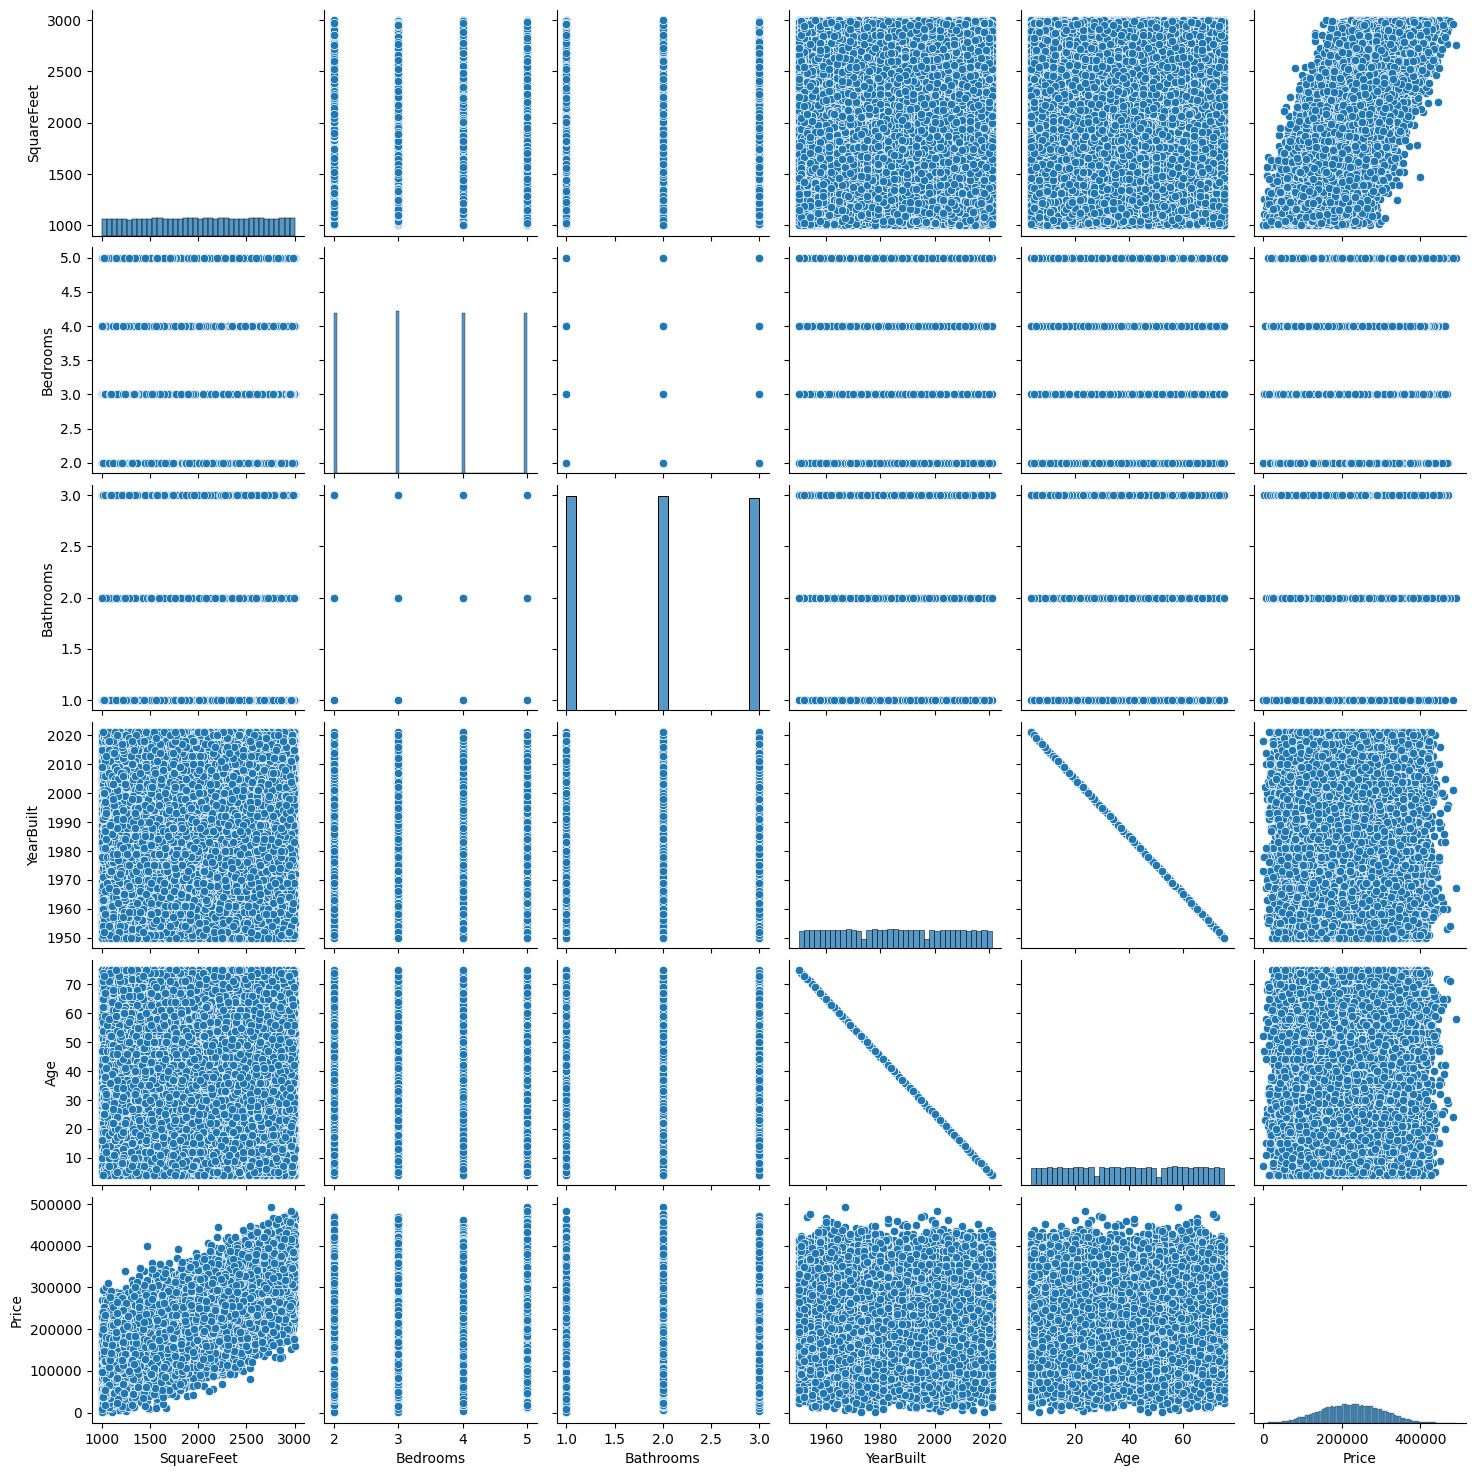

In [13]:
# Pairplot (colored by smoker status)
sns.pairplot(df[['SquareFeet','Bedrooms','Bathrooms','YearBuilt','Age','Price']])
plt.show()

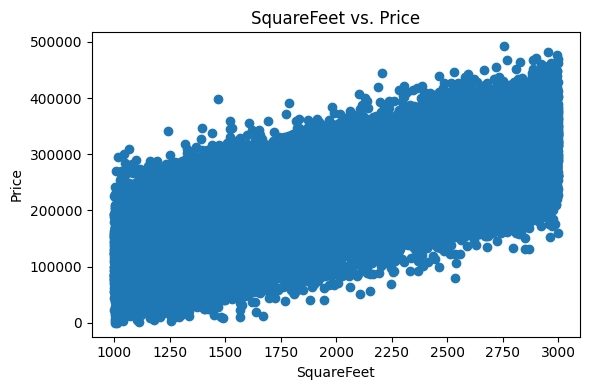

In [14]:
plt.figure(figsize=(6,4))
plt.scatter(df['SquareFeet'], df['Price'])
plt.title('SquareFeet vs. Price')
plt.xlabel('SquareFeet')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

In [15]:
# Check content of "Neighborhood" column
df["Neighborhood"].value_counts() 

Neighborhood
Suburb    16716
Rural     16668
Urban     16594
Name: count, dtype: int64

In [16]:
# Convert into numeric feature (One Hot Encoding)
df = pd.get_dummies(df,drop_first= True)
df.head()

,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Price,Age,Neighborhood_Suburb,Neighborhood_Urban
0,2126,4,1,1969,215355.283618,56,False,False
1,2459,3,2,1980,195014.221626,45,False,False
2,1860,2,1,1970,306891.012076,55,True,False
3,2294,2,1,1996,206786.787153,29,False,True
4,2130,5,2,2001,272436.239065,24,True,False


<Axes: >

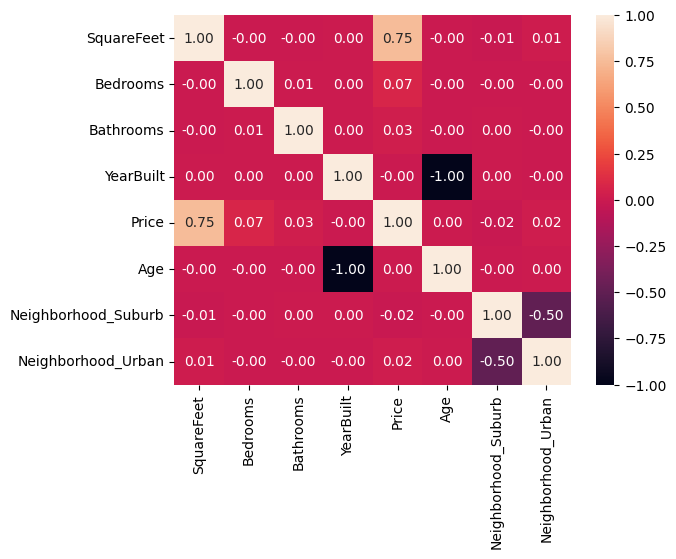

In [17]:
# Correlation analysis
sns.heatmap(df.corr(), annot=True, fmt=".2f")

### Features and label selction

In [18]:
X = df.drop(columns= ['Price','YearBuilt','Age'],axis = 1)
y = df['Price']

In [19]:
# Split data into train and val set
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [22]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate performance
r2score = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

In [23]:
# Print metrics
print("Linear Regression Metrics:")
print(f"R2 Score: {r2score}")
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")

Linear Regression Metrics:
R2 Score: 0.5762298031089357
Mean Squared Error: 2450982051.967825
Mean Absolute Error: 39535.903356182695


In [24]:
feature_names = X.columns
coefs = pd.Series(model.coef_, index=feature_names)
imp   = coefs.abs().sort_values(ascending=False)
print("\nFeatures by importance (|coef|):")
print(imp)


Features by importance (|coef|):
SquareFeet             56911.036370
Bedrooms                5531.367348
Bathrooms               2321.165557
Neighborhood_Urban       668.917221
Neighborhood_Suburb      218.902384
dtype: float64


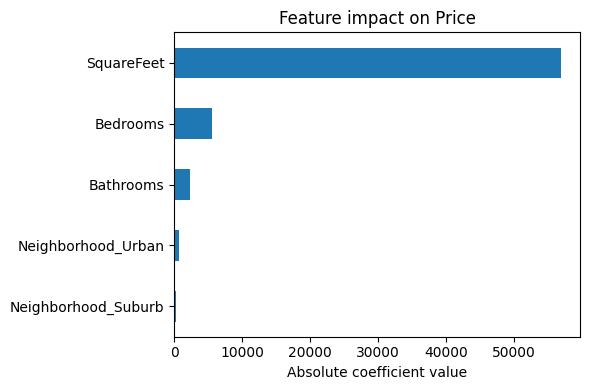

In [25]:
imp.plot.barh(figsize=(6,4))
plt.title("Feature impact on Price")
plt.xlabel("Absolute coefficient value")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Interpreting Model Predictions with Explainable AI (XAI)

In [26]:
X_test_name = pd.DataFrame(X_test, columns=feature_names)

c:\Users\ACER\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


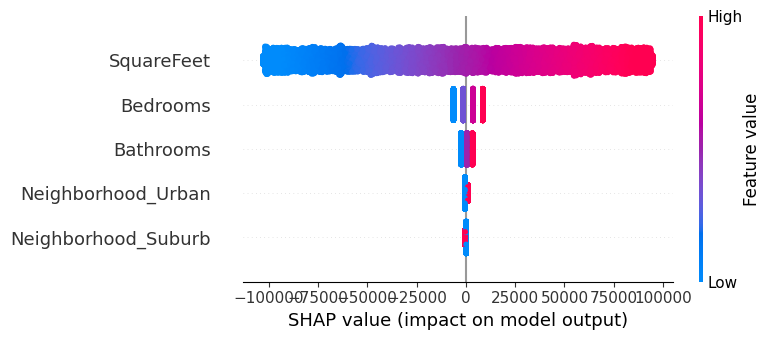

In [27]:
# SHAP: Global and Local Interpretation
import shap
shap.initjs()

# Create the explainer for linear regression
explainer = shap.Explainer(model, X_test_name)
shap_values = explainer(X_test_name)

# Global feature importance summary plot
shap.summary_plot(shap_values, X_test_name)

Color : RED (High Value of features) and BLUE (Low Value of Feature)
- The SHAP summary plot above shows the impact of each feature on the model's predictions.
- Features at the top (like SquareFeet) have the most influence on house price predictions.
- The further from zero, the more that feature pushes the prediction up or down.

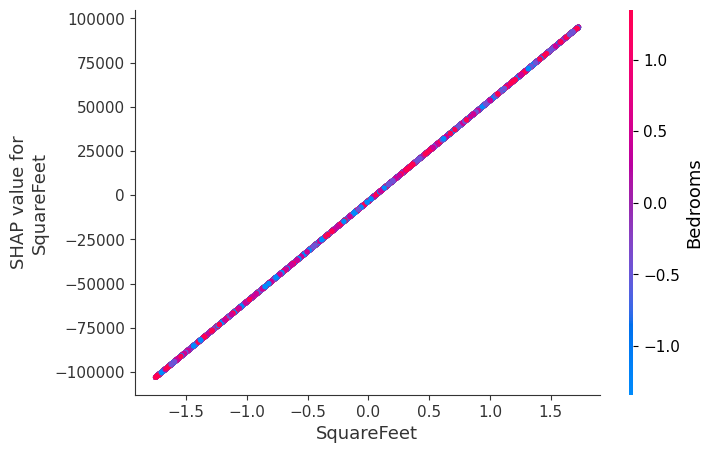

In [28]:
# SHAP: Dependence plot for a specific feature (SquareFeet)

shap.dependence_plot('SquareFeet', shap_values.values, X_test, feature_names=X.columns)

- The SHAP dependence plot above shows how changes in SquareFeet affect the predicted house price.
- As SquareFeet increases, the SHAP value (and thus the predicted price) also increases.
- The color shows the value of Bedrooms, helping to visualize feature interactions.

In [39]:
# LIME: Local Interpretation for a single prediction
import lime
import lime.lime_tabular

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train, feature_names=X.columns, class_names=['Price'], mode='regression'
)

# Explain a single prediction (e.g., the first test sample)
i = 0
exp = lime_explainer.explain_instance(X_test[i], model.predict, num_features=5)
exp.show_in_notebook(show_table=True)

- The LIME explanation above shows which features contributed most to a single prediction.
- Features like SquareFeet and Bedrooms with high values push the prediction higher.
- Negative values (e.g., Neighborhood_Urban) decrease the predicted price.
- This helps explain the model's decision for an individual house in simple terms.


**Baseline**:  **+** (SquareFeet)  **+** (Bedrooms)  **+** (Bathrooms)  **-** (Urban)  **–** (Suburb)  **=** (final prediction)

### Model-Specific Explainability: Linear Regression Coefficients

In [30]:
# Display feature coefficients for the trained linear regression model
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)
print(coef_df)

               Feature   Coefficient
0           SquareFeet  56911.036370
1             Bedrooms   5531.367348
2            Bathrooms   2321.165557
4   Neighborhood_Urban    668.917221
3  Neighborhood_Suburb   -218.902384


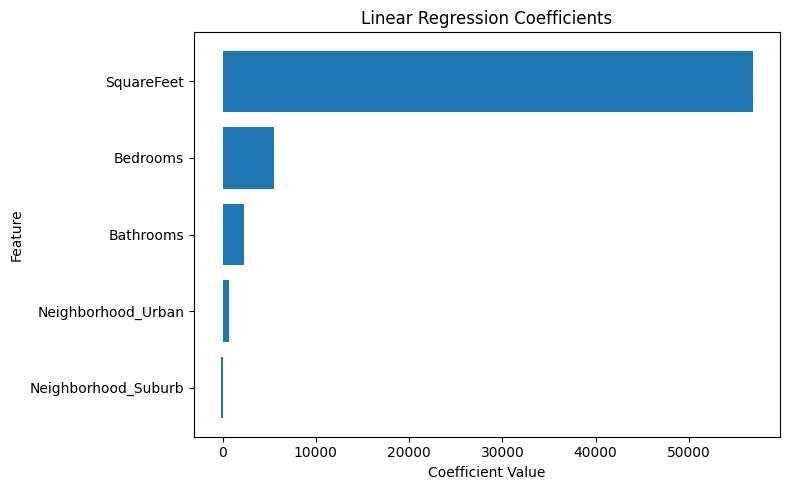

In [31]:
# Visualize the coefficients
plt.figure(figsize=(8,5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.title('Linear Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

- Positive coefficients increase the predicted price, while negative coefficients decrease it.
- The plot above helps us see which features have the strongest impact on the prediction.